# Speech Information Processing – Week 4 Exercise

## Goal
In this notebook, we build a simple classical ASR system:

- GMM-HMM model
- EM training
- Viterbi decoding
- Evaluation
- Model selection (AIC/BIC)

This is a simplified system for understanding the core ideas.

In [1]:
!pip install hmmlearn

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from hmmlearn import hmm

# Step 1: Load YESNO Dataset

We use the YESNO dataset provided by torchaudio.

Each sample contains:
- an audio waveform
- a label (sequence of 0/1 corresponding to "yes"/"no")

Goal:
- Load audio data
- Inspect waveform

In [3]:
import os
import torch
import torchaudio
import matplotlib.pyplot as plt

# make a folder
os.makedirs("../data", exist_ok=True)

dataset = torchaudio.datasets.YESNO(root="../data", download=True)

## Inspect one example

Each sample consists of:
- waveform: audio signal
- sample_rate: sampling rate
- labels: sequence of 0/1 (yes/no)

In [4]:
waveform, sample_rate, labels = dataset[0]

print("Sample rate:", sample_rate)
print("Labels:", labels)
print("Waveform shape:", waveform.shape)

Sample rate: 8000
Labels: [0, 0, 0, 0, 1, 1, 1, 1]
Waveform shape: torch.Size([1, 50800])


## Visualize waveform

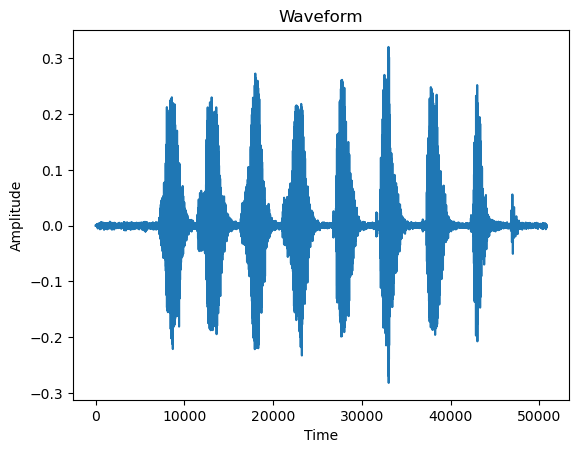

In [5]:
plt.plot(waveform[0].numpy())
plt.title("Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

In [6]:
from IPython.display import Audio
Audio(waveform[0], rate=sample_rate)

### Note on YESNO labels

The YESNO dataset is often described as a sequence of "yes" and "no".

However, the actual recorded speech is **not English**.

- 0 corresponds to **"lo"** (Hebrew for "no")
- 1 corresponds to **"ken"** (Hebrew for "yes")

So an example label sequence like:

    [0, 0, 0, 0, 1, 1, 1, 1]

corresponds to a spoken sequence like:

    lo lo lo lo ken ken ken ken

For simplicity, in this exercise we treat this as a binary sequence,
but keep in mind that the actual words are "lo" and "ken".

## Step 2: Segment the YESNO utterance into 8 word-level segments

The YESNO dataset provides one audio file containing 8 spoken words.

Goal:
- detect speech regions from the waveform
- split the utterance into 8 segments
- align each segment with the given label sequence

In [7]:
import numpy as np

### Define helper functions for segmentation

We use short-time energy (RMS) to detect speech activity.

Main idea:
- compute frame-level energy
- mark high-energy frames as speech
- convert them into time segments

In [8]:
def compute_rms_frames(waveform_1d, frame_length=240, hop_length=80):
    """
    waveform_1d: numpy array of shape (num_samples,)
    returns:
        rms: frame-wise RMS energy, shape (num_frames,)
        frame_starts: sample index of each frame start
    """
    num_samples = len(waveform_1d)
    frame_starts = np.arange(0, max(1, num_samples - frame_length + 1), hop_length)
    rms = []

    for start in frame_starts:
        frame = waveform_1d[start:start + frame_length]
        if len(frame) < frame_length:
            frame = np.pad(frame, (0, frame_length - len(frame)))
        rms_value = np.sqrt(np.mean(frame ** 2))
        rms.append(rms_value)

    return np.array(rms), frame_starts

In [9]:
def smooth_activity_mask(mask, min_silence_frames=3, min_speech_frames=5):
    """
    Fill short silent gaps and remove very short speech bursts.
    """
    mask = mask.copy()

    # Fill short silent gaps
    i = 0
    while i < len(mask):
        if not mask[i]:
            j = i
            while j < len(mask) and not mask[j]:
                j += 1
            gap_len = j - i
            if i > 0 and j < len(mask) and gap_len <= min_silence_frames:
                mask[i:j] = True
            i = j
        else:
            i += 1

    # Remove very short speech bursts
    i = 0
    while i < len(mask):
        if mask[i]:
            j = i
            while j < len(mask) and mask[j]:
                j += 1
            seg_len = j - i
            if seg_len < min_speech_frames:
                mask[i:j] = False
            i = j
        else:
            i += 1

    return mask

In [10]:
def mask_to_segments(mask, frame_starts, frame_length):
    """
    Convert a boolean speech mask into sample-level segments.
    returns list of (start_sample, end_sample)
    """
    segments = []
    i = 0
    while i < len(mask):
        if mask[i]:
            j = i
            while j < len(mask) and mask[j]:
                j += 1
            start_sample = frame_starts[i]
            end_sample = frame_starts[j - 1] + frame_length
            segments.append((int(start_sample), int(end_sample)))
            i = j
        else:
            i += 1
    return segments

### Compute frame energy

In [11]:
waveform_1d = waveform[0].numpy()

# 30 ms frame, 10 ms hop for 8 kHz audio
frame_length = int(0.03 * sample_rate)   # 240
hop_length = int(0.01 * sample_rate)     # 80

rms, frame_starts = compute_rms_frames(
    waveform_1d,
    frame_length=frame_length,
    hop_length=hop_length
)

print("Number of frames:", len(rms))
print("Max RMS:", rms.max())
print("Mean RMS:", rms.mean())

Number of frames: 633
Max RMS: 0.14022239
Mean RMS: 0.028428247


### Detect active speech frames

We choose a threshold relative to the maximum RMS.

In [12]:
threshold = 0.20 * rms.max()
speech_mask = rms > threshold
speech_mask = smooth_activity_mask(
    speech_mask,
    min_silence_frames=4,
    min_speech_frames=6
)

segments = mask_to_segments(speech_mask, frame_starts, frame_length)

print("Detected segments:", len(segments))
print("Segments (sample indices):", segments)

Detected segments: 8
Segments (sample indices): [(7600, 9840), (12160, 14400), (16880, 19200), (21760, 24080), (26960, 29120), (31920, 34080), (37200, 39280), (42480, 43760)]


### Visualize waveform, RMS, and detected segments

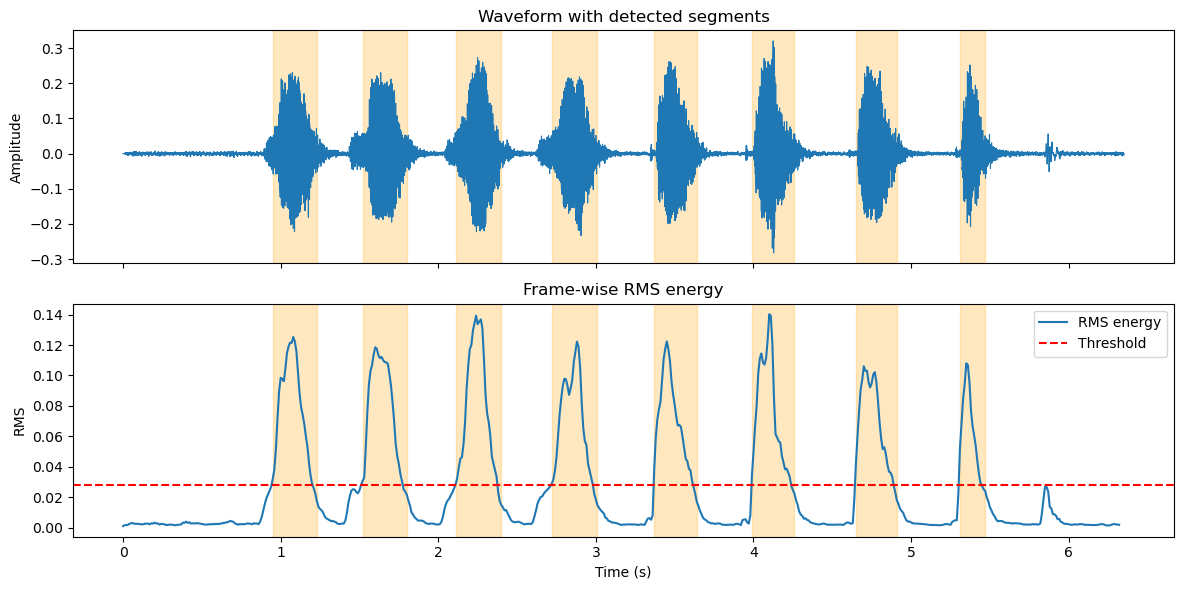

In [13]:
time_wave = np.arange(len(waveform_1d)) / sample_rate
time_rms = frame_starts / sample_rate

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# waveform
axes[0].plot(time_wave, waveform_1d, linewidth=0.8)
axes[0].set_title("Waveform with detected segments")
axes[0].set_ylabel("Amplitude")

for start, end in segments:
    axes[0].axvspan(start / sample_rate, end / sample_rate, color="orange", alpha=0.25)

# RMS
axes[1].plot(time_rms, rms, label="RMS energy")
axes[1].axhline(threshold, color="red", linestyle="--", label="Threshold")
axes[1].set_title("Frame-wise RMS energy")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("RMS")
axes[1].legend()

for start, end in segments:
    axes[1].axvspan(start / sample_rate, end / sample_rate, color="orange", alpha=0.25)

plt.tight_layout()
plt.show()

### Adjust to exactly 8 segments

YESNO contains exactly 8 words.

If energy-based detection does not produce exactly 8 segments,
we fall back to a simple uniform split over the detected speech span.

In [14]:
def force_n_segments_from_span(segments, n_target):
    """
    If segmentation does not produce exactly n_target segments,
    split the full detected speech span uniformly into n_target parts.
    """
    start = segments[0][0]
    end = segments[-1][1]
    boundaries = np.linspace(start, end, n_target + 1).astype(int)
    forced_segments = [(boundaries[i], boundaries[i + 1]) for i in range(n_target)]
    return forced_segments

In [15]:
target_n = len(labels)

if len(segments) != target_n:
    print(f"Detected {len(segments)} segments, but expected {target_n}.")
    print("Using fallback: uniform split over the detected speech span.")
    segments = force_n_segments_from_span(segments, target_n)

print("Final number of segments:", len(segments))
print("Final segments:", segments)

Final number of segments: 8
Final segments: [(7600, 9840), (12160, 14400), (16880, 19200), (21760, 24080), (26960, 29120), (31920, 34080), (37200, 39280), (42480, 43760)]


### Pair each segment with its label

In YESNO:
- 0 = "lo" (no)
- 1 = "ken" (yes)

In [16]:
label_to_word = {0: "lo", 1: "ken"}

segment_info = []
for idx, ((start, end), lab) in enumerate(zip(segments, labels)):
    duration = (end - start) / sample_rate
    word = label_to_word[lab]
    segment_info.append({
        "index": idx,
        "start_sample": start,
        "end_sample": end,
        "duration_sec": duration,
        "label": lab,
        "word": word
    })

for item in segment_info:
    print(item)

{'index': 0, 'start_sample': 7600, 'end_sample': 9840, 'duration_sec': 0.28, 'label': 0, 'word': 'lo'}
{'index': 1, 'start_sample': 12160, 'end_sample': 14400, 'duration_sec': 0.28, 'label': 0, 'word': 'lo'}
{'index': 2, 'start_sample': 16880, 'end_sample': 19200, 'duration_sec': 0.29, 'label': 0, 'word': 'lo'}
{'index': 3, 'start_sample': 21760, 'end_sample': 24080, 'duration_sec': 0.29, 'label': 0, 'word': 'lo'}
{'index': 4, 'start_sample': 26960, 'end_sample': 29120, 'duration_sec': 0.27, 'label': 1, 'word': 'ken'}
{'index': 5, 'start_sample': 31920, 'end_sample': 34080, 'duration_sec': 0.27, 'label': 1, 'word': 'ken'}
{'index': 6, 'start_sample': 37200, 'end_sample': 39280, 'duration_sec': 0.26, 'label': 1, 'word': 'ken'}
{'index': 7, 'start_sample': 42480, 'end_sample': 43760, 'duration_sec': 0.16, 'label': 1, 'word': 'ken'}


### Visualize final 8 segments with labels

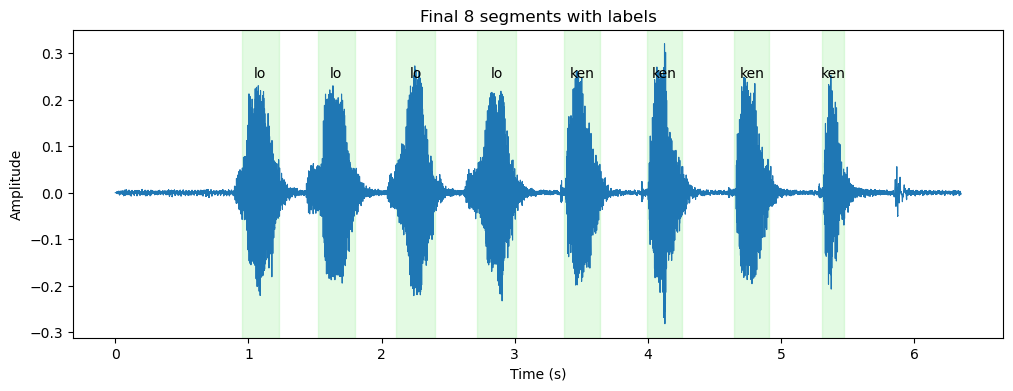

In [17]:
plt.figure(figsize=(12, 4))
plt.plot(time_wave, waveform_1d, linewidth=0.8)
plt.title("Final 8 segments with labels")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

for item in segment_info:
    start = item["start_sample"] / sample_rate
    end = item["end_sample"] / sample_rate
    mid = 0.5 * (start + end)
    plt.axvspan(start, end, color="lightgreen", alpha=0.25)
    plt.text(mid, waveform_1d.max() * 0.8, item["word"], ha="center", va="center", fontsize=10)

plt.show()

### Extract waveform segments

We now cut the original waveform into 8 word-level pieces.

In [18]:
word_waveforms = []
word_labels = []

for item in segment_info:
    start = item["start_sample"]
    end = item["end_sample"]
    seg_wave = waveform[:, start:end]   # keep channel dimension
    word_waveforms.append(seg_wave)
    word_labels.append(item["word"])

print("Number of extracted word segments:", len(word_waveforms))
print("Word labels:", word_labels)

Number of extracted word segments: 8
Word labels: ['lo', 'lo', 'lo', 'lo', 'ken', 'ken', 'ken', 'ken']


### Inspect one segmented word

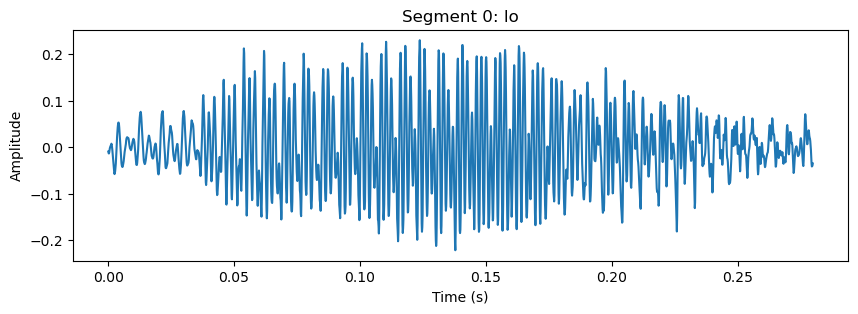

In [19]:
example_idx = 0

seg_wave = word_waveforms[example_idx][0].numpy()
seg_label = word_labels[example_idx]

plt.figure(figsize=(10, 3))
plt.plot(np.arange(len(seg_wave)) / sample_rate, seg_wave)
plt.title(f"Segment {example_idx}: {seg_label}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

## Prepare word-level MFCC features

We now convert each segmented word waveform into MFCC features.

Goal:
- extract one feature sequence for each word segment
- group them by label: "lo" and "ken"

In [20]:
def extract_mfcc_segment(waveform_segment, sample_rate, n_mfcc=13):
    """
    waveform_segment: torch.Tensor of shape (1, num_samples)
    return:
        feats: numpy array of shape (num_frames, n_mfcc)
    """
    mfcc_transform_local = torchaudio.transforms.MFCC(
        sample_rate=sample_rate,
        n_mfcc=n_mfcc
    )
    mfcc = mfcc_transform_local(waveform_segment)   # (1, n_mfcc, T)
    feats = mfcc.squeeze(0).T.numpy()               # (T, n_mfcc)
    return feats

In [21]:
word_features = []
word_names = []

for seg_wave, seg_label in zip(word_waveforms, word_labels):
    feats = extract_mfcc_segment(seg_wave, sample_rate, n_mfcc=13)
    word_features.append(feats)
    word_names.append(seg_label)

print("Number of word segments:", len(word_features))
print("Labels:", word_names)
print("Example feature shape:", word_features[0].shape)

Number of word segments: 8
Labels: ['lo', 'lo', 'lo', 'lo', 'ken', 'ken', 'ken', 'ken']
Example feature shape: (12, 13)


### Separate the segments into two classes
- "lo"
- "ken"

In [22]:
lo_sequences = [f for f, lab in zip(word_features, word_names) if lab == "lo"]
ken_sequences = [f for f, lab in zip(word_features, word_names) if lab == "ken"]

print("Number of lo segments :", len(lo_sequences))
print("Number of ken segments:", len(ken_sequences))

Number of lo segments : 4
Number of ken segments: 4


### Visualize one MFCC from each class

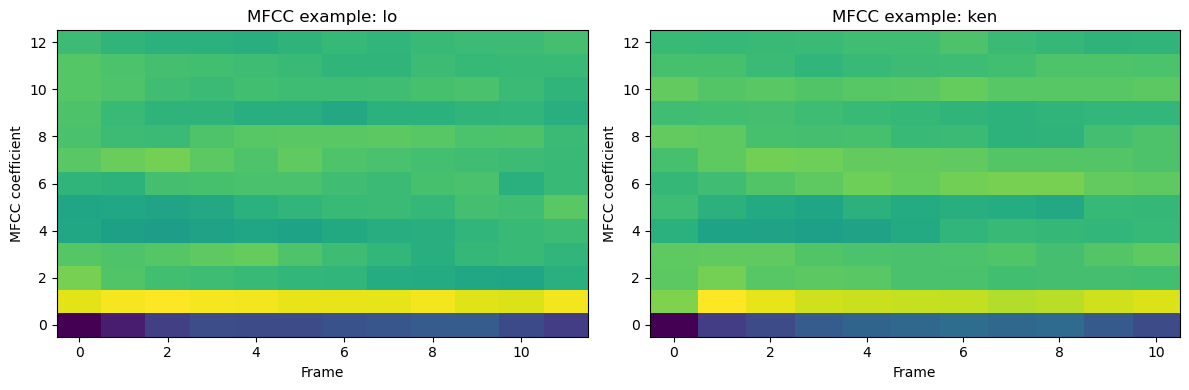

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(lo_sequences[0].T, aspect="auto", origin="lower")
axes[0].set_title("MFCC example: lo")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("MFCC coefficient")

axes[1].imshow(ken_sequences[0].T, aspect="auto", origin="lower")
axes[1].set_title("MFCC example: ken")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("MFCC coefficient")

plt.tight_layout()
plt.show()

# Task 1: Train word-level HMMs

Goal:
- train one HMM for "lo"
- train one HMM for "ken"

This is a simple isolated-word recognition setting.

In [24]:
from hmmlearn import hmm
import numpy as np

### Prepare training arrays for hmmlearn

hmmlearn expects:
- one stacked matrix X
- one list of sequence lengths

In [25]:
def stack_sequences(sequence_list):
    X = np.vstack(sequence_list)
    lengths = [seq.shape[0] for seq in sequence_list]
    return X, lengths

X_lo, lengths_lo = stack_sequences(lo_sequences)
X_ken, lengths_ken = stack_sequences(ken_sequences)

print("X_lo shape:", X_lo.shape)
print("lengths_lo:", lengths_lo)

print("X_ken shape:", X_ken.shape)
print("lengths_ken:", lengths_ken)

X_lo shape: (48, 13)
lengths_lo: [12, 12, 12, 12]
X_ken shape: (40, 13)
lengths_ken: [11, 11, 11, 7]


### Define and train the (3-state, fully connected) HMMs

In [26]:
n_states = 3

lo_model = hmm.GaussianHMM(
    n_components=n_states,
    covariance_type="diag",
    n_iter=50,
    random_state=0
)

ken_model = hmm.GaussianHMM(
    n_components=n_states,
    covariance_type="diag",
    n_iter=50,
    random_state=0
)

lo_model.fit(X_lo, lengths_lo)
ken_model.fit(X_ken, lengths_ken)

print("Training finished.")

Training finished.


In [27]:
print("lo train log-likelihood :", lo_model.score(X_lo, lengths_lo))
print("ken train log-likelihood:", ken_model.score(X_ken, lengths_ken))

lo train log-likelihood : -2342.7486333065744
ken train log-likelihood: -1933.8755213692343


# Task 2: Viterbi Decoding

Goal:
- decode the most likely hidden-state sequence for one word segment

Here we inspect one example from each class.

In [28]:
lo_example = lo_sequences[0]
ken_example = ken_sequences[0]

lo_logprob, lo_states = lo_model.decode(lo_example, algorithm="viterbi")
ken_logprob, ken_states = ken_model.decode(ken_example, algorithm="viterbi")

print("lo example log-prob :", lo_logprob)
print("lo states (first 20):", lo_states[:20])

print("ken example log-prob :", ken_logprob)
print("ken states (first 20):", ken_states[:20])

lo example log-prob : -609.1923036570594
lo states (first 20): [0 0 0 0 2 2 2 2 1 1 1 1]
ken example log-prob : -540.5268553106915
ken states (first 20): [2 0 0 0 1 1 1 1 1 0 0]


### Visualize decoded states

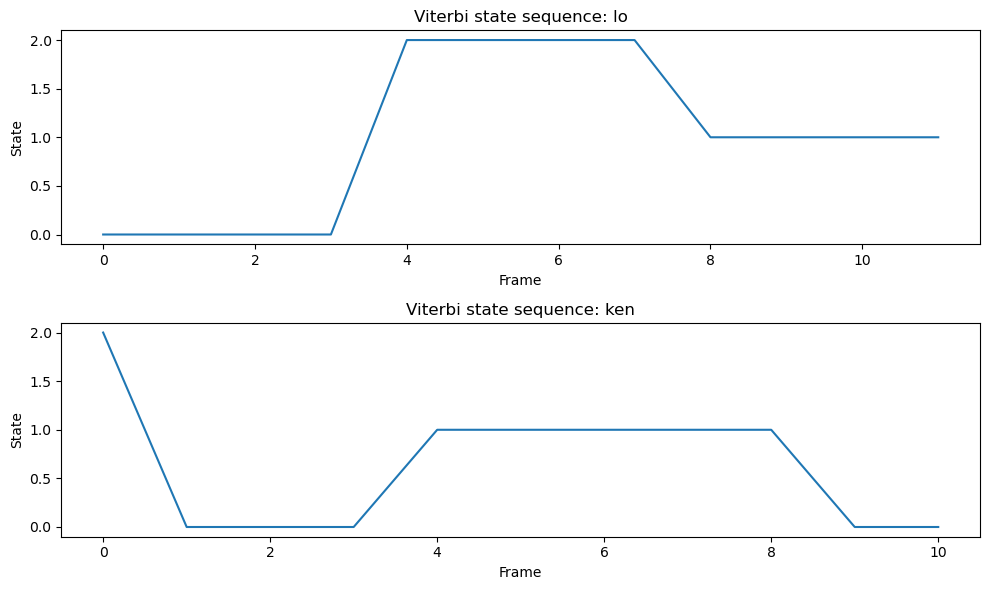

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)

axes[0].plot(lo_states)
axes[0].set_title("Viterbi state sequence: lo")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("State")

axes[1].plot(ken_states)
axes[1].set_title("Viterbi state sequence: ken")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("State")

plt.tight_layout()
plt.show()

### Interpretation

The state sequence is not the word itself.

It is the most likely sequence of hidden HMM states that explains the MFCC frames of that word.

# Task 3: Classify each word segment

Goal:
- decide whether a segment is "lo" or "ken"

Method:
- compute the score under both models
- choose the larger one

In [30]:
def classify_segment(feats, lo_model, ken_model):
    score_lo = lo_model.score(feats)
    score_ken = ken_model.score(feats)

    pred = "lo" if score_lo > score_ken else "ken"
    return pred, score_lo, score_ken

In [31]:
predictions = []
score_table = []

for feats, true_lab in zip(word_features, word_names):
    pred_lab, score_lo, score_ken = classify_segment(feats, lo_model, ken_model)
    predictions.append(pred_lab)
    score_table.append((true_lab, pred_lab, score_lo, score_ken))

for row in score_table:
    print(row)

('lo', 'lo', -608.6303344226651, -1028.5458958752542)
('lo', 'lo', -572.6848553342531, -969.2613791774286)
('lo', 'lo', -582.836847425789, -1043.7103515957083)
('lo', 'lo', -578.5965961238672, -1085.7897334149197)
('ken', 'ken', -878.7856811383903, -540.483341329464)
('ken', 'ken', -968.1821286537686, -531.4168905802529)
('ken', 'ken', -938.223392870002, -529.7565656302944)
('ken', 'ken', -604.2840270818901, -332.2187238292232)


### Compute accuracy

In [32]:
accuracy = np.mean([p == t for p, t in zip(predictions, word_names)])
print("Word classification accuracy:", accuracy)

Word classification accuracy: 1.0


### Confusion counts

In [33]:
from collections import Counter

pairs = list(zip(word_names, predictions))
counts = Counter(pairs)

print("Confusion counts:")
for k, v in counts.items():
    print(k, ":", v)

Confusion counts:
('lo', 'lo') : 4
('ken', 'ken') : 4


# Task 4: Model Selection with AIC / BIC

Goal:
- compare different numbers of HMM states

We test:
- 2 states
- 3 states
- 4 states

In [34]:
def approx_num_params_gaussian_hmm(model, n_features):
    n_states = model.n_components

    # initial distribution
    start_params = n_states - 1

    # transition matrix
    trans_params = n_states * (n_states - 1)

    # means
    mean_params = n_states * n_features

    # diagonal covariances
    cov_params = n_states * n_features

    return start_params + trans_params + mean_params + cov_params

In [35]:
def compute_aic(logL, k):
    return -2 * logL + 2 * k

def compute_bic(logL, k, n):
    return -2 * logL + k * np.log(n)

### Compare models for the "lo" class

In [36]:
results_lo = []

for n_states_test in [2, 3, 4]:
    model_test = hmm.GaussianHMM(
        n_components=n_states_test,
        covariance_type="diag",
        n_iter=50,
        random_state=0
    )
    model_test.fit(X_lo, lengths_lo)

    logL = model_test.score(X_lo, lengths_lo)
    k = approx_num_params_gaussian_hmm(model_test, X_lo.shape[1])
    aic = compute_aic(logL, k)
    bic = compute_bic(logL, k, X_lo.shape[0])

    results_lo.append((n_states_test, logL, aic, bic))

for row in results_lo:
    print(f"lo | states={row[0]} | logL={row[1]:.2f} | AIC={row[2]:.2f} | BIC={row[3]:.2f}")

lo | states=2 | logL=-2408.15 | AIC=4926.30 | BIC=5029.21
lo | states=3 | logL=-2342.75 | AIC=4857.50 | BIC=5018.42
lo | states=4 | logL=-2271.78 | AIC=4781.56 | BIC=5004.24


### Compare models for the "ken" class

In [37]:
results_ken = []

for n_states_test in [2, 3, 4]:
    model_test = hmm.GaussianHMM(
        n_components=n_states_test,
        covariance_type="diag",
        n_iter=50,
        random_state=0
    )
    model_test.fit(X_ken, lengths_ken)

    logL = model_test.score(X_ken, lengths_ken)
    k = approx_num_params_gaussian_hmm(model_test, X_ken.shape[1])
    aic = compute_aic(logL, k)
    bic = compute_bic(logL, k, X_ken.shape[0])

    results_ken.append((n_states_test, logL, aic, bic))

for row in results_ken:
    print(f"ken | states={row[0]} | logL={row[1]:.2f} | AIC={row[2]:.2f} | BIC={row[3]:.2f}")

Model is not converging.  Current: -1998.1230103929852 is not greater than -1998.1230098063095. Delta is -5.866756964678643e-07


ken | states=2 | logL=-1998.12 | AIC=4106.25 | BIC=4199.13
ken | states=3 | logL=-1933.88 | AIC=4039.75 | BIC=4184.99
ken | states=4 | logL=-1882.27 | AIC=4002.54 | BIC=4203.52


### Note on convergence warning

A very small decrease in log-likelihood can occur due to numerical precision.

In this case, the change is negligible, so we consider the model converged.

## Interpretation of AIC / BIC Results

We compare models with different numbers of hidden states.

Observations:
- Log-likelihood improves as model size increases
- AIC and BIC may select different models

Key questions:
- Does increasing model complexity always help?
- Which model should we choose?

We will analyze:
- AIC vs BIC behavior
- Differences between "lo" and "ken"

In [38]:
import pandas as pd

df_lo = pd.DataFrame(results_lo, columns=["n_states", "logL", "AIC", "BIC"])
df_ken = pd.DataFrame(results_ken, columns=["n_states", "logL", "AIC", "BIC"])

print("=== LO ===")
display(df_lo)

print("=== KEN ===")
display(df_ken)

=== LO ===


,n_states,logL,AIC,BIC
0,2,-2408.148264,4926.296528,5029.212584
1,3,-2342.748633,4857.497267,5018.420554
2,4,-2271.781577,4781.563155,5004.236075


=== KEN ===


,n_states,logL,AIC,BIC
0,2,-1998.123010,4106.246021,4199.134391
1,3,-1933.875521,4039.751043,4184.994676
2,4,-1882.272211,4002.544421,4203.521076


In [39]:
best_lo_aic = df_lo.loc[df_lo["AIC"].idxmin()]
best_lo_bic = df_lo.loc[df_lo["BIC"].idxmin()]

best_ken_aic = df_ken.loc[df_ken["AIC"].idxmin()]
best_ken_bic = df_ken.loc[df_ken["BIC"].idxmin()]

print("Best LO (AIC):", best_lo_aic["n_states"])
print("Best LO (BIC):", best_lo_bic["n_states"])

print("Best KEN (AIC):", best_ken_aic["n_states"])
print("Best KEN (BIC):", best_ken_bic["n_states"])

Best LO (AIC): 4.0
Best LO (BIC): 4.0
Best KEN (AIC): 4.0
Best KEN (BIC): 3.0


### Interpretation

General pattern:
- Increasing the number of states improves log-likelihood
- This is expected (more flexible models fit better)

AIC:
- Prefers more complex models
- Focuses on predictive performance

BIC:
- Penalizes complexity more strongly
- Prefers simpler models

Observed result:
- "lo": both AIC and BIC may prefer larger models
- "ken": AIC prefers larger model, BIC prefers smaller model

Conclusion:
- Model selection depends on the balance between fit and complexity

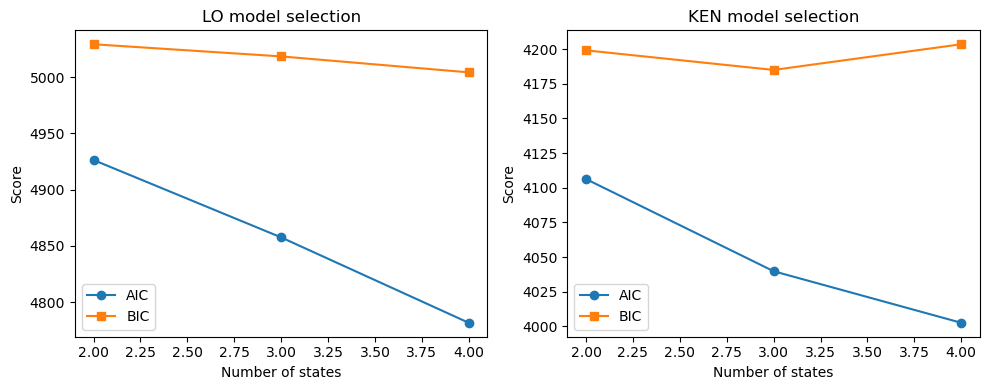

In [40]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(df_lo["n_states"], df_lo["AIC"], marker="o", label="AIC")
plt.plot(df_lo["n_states"], df_lo["BIC"], marker="s", label="BIC")
plt.title("LO model selection")
plt.xlabel("Number of states")
plt.ylabel("Score")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df_ken["n_states"], df_ken["AIC"], marker="o", label="AIC")
plt.plot(df_ken["n_states"], df_ken["BIC"], marker="s", label="BIC")
plt.title("KEN model selection")
plt.xlabel("Number of states")
plt.ylabel("Score")
plt.legend()

plt.tight_layout()
plt.show()

### Key Takeaways

- More complex models always increase likelihood
- AIC allows more flexibility
- BIC is more conservative

Important:
- Model selection is not only about fit
- It is about generalization

Final message:
A good model balances:
- accuracy (fit)
- simplicity (complexity)

# Demo: Pretrained Continuous Speech Recognition

In the main exercise, we built a simplified ASR system using GMM-HMM.

Now we run a pretrained continuous speech recognizer.

Goal:
- observe continuous speech recognition output
- connect the simplified exercise to a real ASR system

Note:
- this system already includes:
  • acoustic model
  • pronunciation lexicon
  • language model

In [41]:
!pip install vosk sounddevice

## Download a pretrained model

We use a small English model for demonstration.

In [42]:
import os
import urllib.request
import zipfile

model_url = "https://alphacephei.com/vosk/models/vosk-model-small-en-us-0.15.zip"
model_zip = "model.zip"
model_dir = "model"

if not os.path.exists(model_dir):
    print("Downloading model...")
    urllib.request.urlretrieve(model_url, model_zip)

    print("Extracting...")
    with zipfile.ZipFile(model_zip, "r") as zip_ref:
        zip_ref.extractall()

    os.rename("vosk-model-small-en-us-0.15", model_dir)

print("Model ready.")

Model ready.


## Run recognition on an audio file

We use one example from the YESNO dataset.

In [43]:
import wave
from vosk import Model, KaldiRecognizer

## Resample the audio to 16 kHz for Vosk

The pretrained Vosk model expects 16 kHz audio,
while the YESNO dataset uses 8 kHz.

So we resample before recognition.

In [44]:
import torchaudio
import soundfile as sf

target_sample_rate = 16000

resampler = torchaudio.transforms.Resample(
    orig_freq=sample_rate,
    new_freq=target_sample_rate
)

waveform_16k = resampler(waveform)

print("Original sample rate:", sample_rate)
print("New sample rate:", target_sample_rate)
print("Original shape:", waveform.shape)
print("Resampled shape:", waveform_16k.shape)

sf.write("test_16k.wav", waveform_16k[0].numpy(), target_sample_rate)

Original sample rate: 8000
New sample rate: 16000
Original shape: torch.Size([1, 50800])
Resampled shape: torch.Size([1, 101600])


In [45]:
import wave
from vosk import Model, KaldiRecognizer

wf = wave.open("test_16k.wav", "rb")

model = Model("model")
rec = KaldiRecognizer(model, wf.getframerate())

result_text = ""

while True:
    data = wf.readframes(4000)
    if len(data) == 0:
        break
    if rec.AcceptWaveform(data):
        result_text += rec.Result()

result_text += rec.FinalResult()

print(result_text)

LOG (VoskAPI:ReadDataFiles():model.cc:213) Decoding params beam=10 max-active=3000 lattice-beam=2
LOG (VoskAPI:ReadDataFiles():model.cc:216) Silence phones 1:2:3:4:5:6:7:8:9:10
LOG (VoskAPI:RemoveOrphanNodes():nnet-nnet.cc:948) Removed 0 orphan nodes.
LOG (VoskAPI:RemoveOrphanComponents():nnet-nnet.cc:847) Removing 0 orphan components.
LOG (VoskAPI:ReadDataFiles():model.cc:248) Loading i-vector extractor from model/ivector/final.ie
LOG (VoskAPI:ComputeDerivedVars():ivector-extractor.cc:183) Computing derived variables for iVector extractor
LOG (VoskAPI:ComputeDerivedVars():ivector-extractor.cc:204) Done.
LOG (VoskAPI:ReadDataFiles():model.cc:282) Loading HCL and G from model/graph/HCLr.fst model/graph/Gr.fst
LOG (VoskAPI:ReadDataFiles():model.cc:303) Loading winfo model/graph/phones/word_boundary.int


{
  "text" : "learn learn learn learn can can can can"
}


### Interpretation of the pretrained ASR output

The Vosk recognizer is an English pretrained model.

However, the YESNO dataset contains Hebrew words:
- 0 = "lo"
- 1 = "ken"

So the recognizer maps the input to the closest English words it knows.

Example:
- "lo" may be mapped to an English-like word
- "ken" may be mapped to "can" or similar forms

This demonstrates an important lesson:

A pretrained ASR system may run correctly, but recognition quality depends on
- language match
- vocabulary match
- acoustic conditions

# Demo: Pretrained Continuous Speech Recognition

For the continuous-speech demo, we use a synthetic English speech sample from Week 2.

Why this is better than YESNO:
- the pretrained recognizer is English
- the synthetic speech is also English
- this makes the recognition output easier to interpret

Goal:
- run a pretrained recognizer
- compare the output with the intended sentence
- connect our simplified HMM exercise to a practical ASR system

# Generate Synthetic Speech (TTS)

We generate speech directly as a waveform (no external tools needed).

In [46]:
!pip install deep_phonemizer

In [47]:
import torch
import torchaudio
from torchaudio.pipelines import TACOTRON2_WAVERNN_PHONE_LJSPEECH

bundle = TACOTRON2_WAVERNN_PHONE_LJSPEECH

processor = bundle.get_text_processor()
tacotron2 = bundle.get_tacotron2()
vocoder = bundle.get_vocoder()

text = "this is a simple speech recognition demo"

with torch.inference_mode():
    processed, lengths = processor(text)
    spec, _, _ = tacotron2.infer(processed, lengths)
    waveforms, _ = vocoder(spec)

torchaudio.save("tts_sample.wav", waveforms[0:1], 22050)

print("Saved tts_sample.wav")

/opt/miniconda3/envs/sip/lib/python3.10/site-packages/dp/model/model.py:69: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(encoder_layer=encoder_layer,


Saved tts_sample.wav


## Run ASR on generated speech

In [48]:
import wave
from vosk import Model, KaldiRecognizer

wf = wave.open("tts_sample.wav", "rb")

model = Model("model")
rec = KaldiRecognizer(model, wf.getframerate())

result_text = ""

while True:
    data = wf.readframes(4000)
    if len(data) == 0:
        break
    if rec.AcceptWaveform(data):
        result_text += rec.Result()

result_text += rec.FinalResult()

print(result_text)

LOG (VoskAPI:ReadDataFiles():model.cc:213) Decoding params beam=10 max-active=3000 lattice-beam=2
LOG (VoskAPI:ReadDataFiles():model.cc:216) Silence phones 1:2:3:4:5:6:7:8:9:10
LOG (VoskAPI:RemoveOrphanNodes():nnet-nnet.cc:948) Removed 0 orphan nodes.
LOG (VoskAPI:RemoveOrphanComponents():nnet-nnet.cc:847) Removing 0 orphan components.
LOG (VoskAPI:ReadDataFiles():model.cc:248) Loading i-vector extractor from model/ivector/final.ie
LOG (VoskAPI:ComputeDerivedVars():ivector-extractor.cc:183) Computing derived variables for iVector extractor
LOG (VoskAPI:ComputeDerivedVars():ivector-extractor.cc:204) Done.
LOG (VoskAPI:ReadDataFiles():model.cc:282) Loading HCL and G from model/graph/HCLr.fst model/graph/Gr.fst
LOG (VoskAPI:ReadDataFiles():model.cc:303) Loading winfo model/graph/phones/word_boundary.int


{
  "text" : "this is a simple speech recognition done them"
}


### Interpretation of the ASR output

The pretrained recognizer works well on the synthetic English speech.

Observed result:
- most of the sentence is recognized correctly
- the last word "demo" is misrecognized

This illustrates an important point:

Even when the input language matches the recognizer,
ASR output is still affected by
- acoustic variation
- pronunciation
- language-model preference

So practical ASR is strong, but not perfect.